In [2]:
import os
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr

from stuff import (
    add_river_coordinates,
    fill_nans_with_nearest,
    get_river_indices,
    reformat_river_dataset,
    regrid_from_norkyst,
)

In [5]:

PARAMETERS = ["temperature", "salinity", "u_eastward", "v_northward"]

### Data fetching
Process downloaded NorKyst data (ROMS model for the Norwegian coast).
This data will be used for the boundary conditions, which are set up as forcing.
Skip if you have it already.

In [6]:
#DATA_DIR = Path("/home/eya/src/gcp-chem-sim-private/data/input/NorKyst2/")
DATA_DIR = Path("/home/eya/src/gcp-chem-sim-private/data/input/NorKyst3/")
# List all .nc files in the folder (non-recursive)
#files = [f.name for f in data_dir.glob("*.nc")]
#print(files)
def list_local_files():
    return [f.name for f in DATA_DIR.glob("*.nc")]


NameError: name 'Path' is not defined

In [6]:
# names are like 20240101, so put an appropriate string to get specific files
month_string = "2020" #"202001"
#files = sorted([s for s in list_opendap_files() if month_string in s])
#urls = [os.path.join(OPENDAP_URL, x) for x in files]
#dss = [xr.open_dataset(url)[PARAMETERS] for url in urls]
files = sorted([name for name in list_local_files() if month_string in name])
paths = [DATA_DIR / name for name in files]
dss = [xr.open_dataset(path)[PARAMETERS] for path in paths]

In [7]:
ds = xr.combine_by_coords(dss, combine_attrs="override")  # downloading, takes a while

: 

In [ ]:
encoding = {var: {"zlib": True, "complevel": 5} for var in ds.data_vars}
ds.to_netcdf(
    os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input", f"NorKyst-800m_ZDEPTHS_avg2_{month_string}.nc"),
    encoding=encoding,
)

In [ ]:
del ds, dss, files, encoding, month_string
##del ds, dss, urls, files, encoding, month_string

### Regridding
Open the downloaded datasets and regrid them to the coordinates from a bathymetry file.

In [3]:
FILES = sorted(
    os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input", f)
    for f in os.listdir(os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input"))
    if f.startswith("NorKyst-800m_ZDEPTHS_avg_")
)
FILES

['/home/eya/src/gcp-chem-sim-private/data/input/NorKyst-800m_ZDEPTHS_avg_2020.nc']

In [4]:
ds_grid = xr.open_dataset(os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input","bathymetry_19to67.nc"))

In [5]:
lat_diff = np.diff(ds_grid["lat"].values)[0]
lat_faces = np.zeros(shape=ds_grid["lat"].values.shape[0] + 1)
lat_faces[0] = ds_grid["lat"].values[0] - lat_diff / 2
lat_faces[1:] = ds_grid["lat"].values + lat_diff / 2

In [6]:
lon_diff = np.diff(ds_grid["lon"].values)[0]
lon_faces = np.zeros(shape=ds_grid["lon"].values.shape[0] + 1)
lon_faces[0] = ds_grid["lon"].values[0] - lon_diff / 2
lon_faces[1:] = ds_grid["lon"].values + lon_diff / 2

In [7]:
z_faces = ds_grid.z_faces.values
z_centers = [(z_faces[i] + z_faces[i + 1]) / 2 for i in range(len(z_faces) - 1)]
ds_out_c = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)
ds_out_u = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], lon_faces, {"units": "degrees_east"}),
    }
)
ds_out_v = xr.Dataset(
    {
        "lat": (["lat"], lat_faces, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)

In [8]:
time_list = []
temp_list = []
salt_list = []
u_list = []
v_list = []

regridder_rho, regridder_u, regridder_v = None, None, None
for file in FILES:
    ds_in = xr.open_dataset(file)
    new_time = pd.date_range(start=ds_in.time[0].values, end=ds_in.time[-1].values, freq="D")
    ds_in = ds_in.reindex(time=new_time, method="ffill")
    regridder_rho, regridder_u, regridder_v, np_time, np_temp, np_salt, np_u, np_v = regrid_from_norkyst(
        regridder_rho, regridder_u, regridder_v, ds_in, ds_out_c, ds_out_u, ds_out_v, np.array(z_centers)
    )
    time_list.append(np_time)
    temp_list.append(np_temp)
    salt_list.append(np_salt)
    u_list.append(np_u)
    v_list.append(np_v)
    print(f"File {file} processed.")

File /home/eya/src/gcp-chem-sim-private/data/input/NorKyst-800m_ZDEPTHS_avg_2020.nc processed.


In [9]:
np_time = np.concatenate(time_list, axis=0)
np_temp = np.concatenate(temp_list, axis=0).astype(np.float32)
np_salt = np.concatenate(salt_list, axis=0).astype(np.float32)
np_u = np.concatenate(u_list, axis=0).astype(np.float32)
np_v = np.concatenate(v_list, axis=0).astype(np.float32)

In [10]:
Tout_lambda = np.zeros_like(np_temp)
Sout_lambda = np.zeros_like(np_salt)
Uout_lambda = np.zeros_like(np_u)
Vout_lambda = np.zeros_like(np_v)

In [11]:
dsout = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], Tout_lambda),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], Sout_lambda),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], Uout_lambda),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], Vout_lambda),
    },
    coords={
        "time": np_time,
        "Nz": z_centers,
        "Nz_faces": z_faces,
        "Ny": ds_grid["lat"].values,
        "Ny_faces": lat_faces,
        "Nx": ds_grid["lon"].values,
        "Nx_faces": lon_faces,
    },
)

In [12]:
dsout

<xarray.Dataset> Size: 258MB
Dimensions:   (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
               Nz_faces: 18)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz        (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -4.0 -2.5 -1.5 -0.5
  * Ny        (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx        (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces  (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces  (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces  (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float32 32MB nan nan nan nan ... nan nan nan
    T_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float32 32MB nan nan nan nan ... nan nan nan
    S_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float32 33MB nan nan nan ... nan nan nan
    u_lambda  (time, Nz, Ny, Nx_faces) float32 33MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float32 32MB nan nan nan ... nan nan nan
    v_lambda  (time, Nz, Ny_faces, Nx) float32 32MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [13]:
z_level = -1

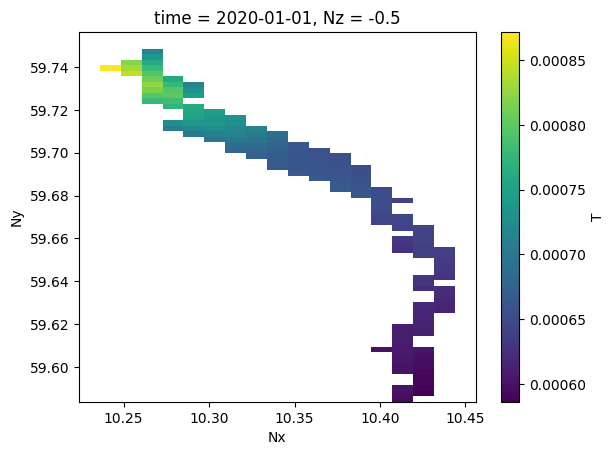

In [14]:
dsout.T.isel(time=0, Nz=z_level).plot()

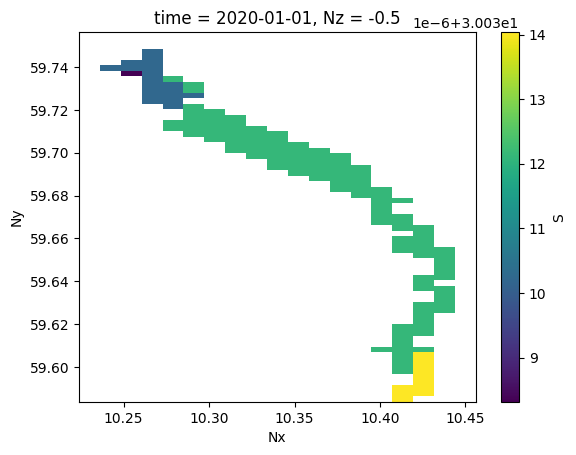

In [15]:
dsout.S.isel(time=0, Nz=z_level).plot()

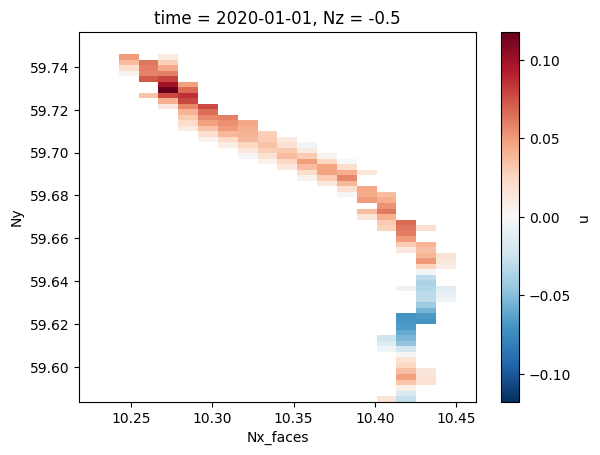

In [16]:
dsout.u.isel(time=0, Nz=z_level).plot()

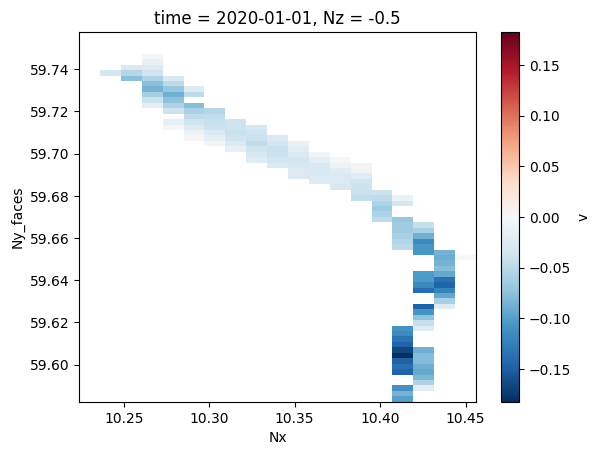

In [17]:
dsout.v.isel(time=0, Nz=z_level).plot()

### Prepare the forcing dataset

In [18]:
ds = dsout.copy(deep=True)

In [19]:
np_z_centers = (ds_grid.z_faces.values[:-1] + ds_grid.z_faces.values[1:]) / 2
oy, ox, oz = (value for value in ds_grid.sizes.values())
np_mask = (np_z_centers > ds_grid.h.values[..., np.newaxis]).astype(int).transpose(2, 0, 1)

In [20]:
np_mask_u = np.zeros((oz - 1, oy, ox + 1))
np_mask_u[:, :, :-1] = np_mask
np_mask_u[:, :, 1:] = np.where(np_mask_u[:, :, 1:] == 0, np_mask, np_mask_u[:, :, 1:])

In [21]:
np_mask_v = np.zeros((oz - 1, oy + 1, ox))
np_mask_v[:, :-1, :] = np_mask
np_mask_v[:, 1:, :] = np.where(np_mask_v[:, 1:, :] == 0, np_mask, np_mask_v[:, 1:, :])

In [22]:
ds.T.values = fill_nans_with_nearest(ds.T) * np_mask
ds.S.values = fill_nans_with_nearest(ds.S) * np_mask
ds.u.values = fill_nans_with_nearest(ds.u) * np_mask_u
ds.v.values = fill_nans_with_nearest(ds.v) * np_mask_v

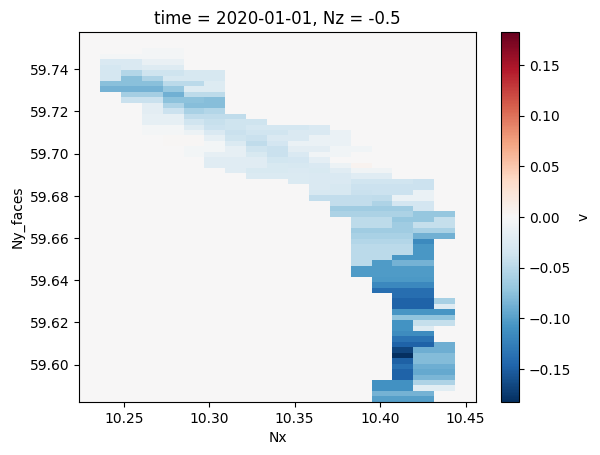

In [23]:
ds.v.isel(time=0, Nz=-1).plot()

Check once again for data gaps in the downloaded datasets

In [24]:
ds = ds.sortby("time")

In [25]:
ds

<xarray.Dataset> Size: 387MB
Dimensions:   (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
               Nz_faces: 18)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz        (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -4.0 -2.5 -1.5 -0.5
  * Ny        (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx        (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces  (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces  (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces  (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    T_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float64 67MB -0.0 -0.0 -0.0 ... 0.0 0.0
    u_lambda  (time, Nz, Ny, Nx_faces) float32 33MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float64 64MB -0.0 -0.0 -0.0 ... -0.0 -0.0
    v_lambda  (time, Nz, Ny_faces, Nx) float32 32MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [26]:
new_time = pd.date_range(start=ds.time[0].values, end=ds.time[-1].values, freq="D")
new_time[~new_time.isin(ds.time.values)]  # this shows which dates are missing in the original data

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [27]:
ds = ds.reindex(time=new_time, method="ffill")

Fill in lambdas for the sourthern boundary conditions.
Lambdas that -1 < lambda < 1 are relaxation rates.
Lambdas > 2 mean flux in x direction (west to east).
Lambdas < -1 mean flux in y direction (south to north).

In [28]:
southern_edge = 10  # use relaxation at 10 southernmost 'layers' at all depths
lambda_relaxation = 1 / (60 * 60 * 24)

In [29]:
ds["NUT"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["NUT_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))
ds["Ci_free"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T.values))
ds["Ci_free_lambda"] = (["time", "Nz", "Ny", "Nx"], np.zeros_like(ds.T_lambda.values))

In [30]:
ds["T_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["T_lambda"] = ds["T_lambda"].astype(np.float32)
ds["S_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["S_lambda"] = ds["S_lambda"].astype(np.float32)
ds["NUT_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["NUT_lambda"] = ds["NUT_lambda"].astype(np.float32)
ds["Ci_free_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["Ci_free_lambda"] = ds["Ci_free_lambda"].astype(np.float32)
ds["u_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_u[:, :southern_edge, :]
ds["u_lambda"] = ds["u_lambda"].astype(np.float32)
ds["v_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_v[:, :southern_edge, :]
ds["v_lambda"] = ds["v_lambda"].astype(np.float32)

In [31]:
ds["T"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["T"][:, :, :, :]
ds["S"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :]
ds["NUT"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :]
ds["Ci_free"][:, :, :, :] = np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :]
ds["u"][:, :, :, :] = np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :]
ds["v"][:, :, :, :] = np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :]

In [32]:
def fill_bgh_var(df, da, repeat=None):
    arr = df.values[:, 1:]
    arr = arr[:, ::-1]
    if repeat is None:
        repeat = max(0, da.shape[1] - arr.shape[1])
    first_col = arr[:, [0]]
    extra_cols = np.repeat(first_col, repeat, axis=1)
    arr = np.hstack((extra_cols, arr))  # add bottom layers
    arr = arr[:, :da.shape[1]]  # trim to match target depth levels
    arr = np.vstack((arr, arr[[-1], :]))  # add the last day
    arr = arr[:, :, None, None]
    arr = np.tile(arr, (1, 1, da.shape[2], da.shape[3]))
    return xr.DataArray(arr, dims=da.dims, coords=da.coords, attrs=da.attrs).astype(np.float32)

In [33]:
df_NUT = pd.read_csv(os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input", "Sea_boundary","NUT.csv"), sep=";")
ds["NUT"] = fill_bgh_var(df_NUT, ds["S"])
# ds_new["NUT"] = fill_bgh_var(df_NUT, ds_new["S"])
# ds_new["NUT_lambda"] = ds_new["sea_lambda"]

In [34]:
ds["Ci_free"] = xr.full_like(ds["T"], fill_value=0.01, dtype=np.float32)
ds["NUT"]

<xarray.DataArray 'NUT' (time: 366, Nz: 17, Ny: 67, Nx: 19)> Size: 32MB
array([[[[10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         ...,
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ]],

        [[10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
         [10.221318 , 10.221318 , 10.221318 , ..., 10.221318 ,
          10.221318 , 10.221318 ],
...
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ]],

        [[11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         ...,
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ],
         [11.579321 , 11.579321 , 11.579321 , ..., 11.579321 ,
          11.579321 , 11.579321 ]]]],
      shape=(366, 17, 67, 19), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz       (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -4.0 -2.5 -1.5 -0.5
  * Ny       (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx       (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45

### Add rivers

In [35]:
def get_river(file_name, layers_num=3):
    df_BGC_variable = pd.read_csv(
        os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input", "Rivers",file_name), sep=";", skiprows=1 #sep="\t"
    )
    df = df_BGC_variable
    arr = np.abs(df.values[:, 3]) # we read information for the substance discharge (umol/s) from the 4th column instead of concentration in column 3
    arr = np.repeat(arr[:, None], layers_num, axis=1)
    # pad to 366 rows for leap years by repeating last row
    n_times = ds.sizes["time"]
    if arr.shape[0] < n_times:
        pad = np.repeat(arr[[-1], :], n_times - arr.shape[0], axis=0)
        arr = np.vstack([arr, pad])
    return arr

def get_river_dis(file_name, column, layers_num=3):
    df_water_discharge = pd.read_csv(
        os.path.join(Path.home(),  "src", "gcp-chem-sim-private", "data", "input", "Rivers",file_name),  sep=";", skiprows=1 #sep="\t"
    )
    df = df_water_discharge
    arr = np.abs(df.values[:, column]) # we read information for the substance discharge (umol/s) from the 4th column instead of concentration in column 3
    arr = np.repeat(arr[:, None], layers_num, axis=1)
    # pad to 366 rows for leap years by repeating last row
    n_times = ds.sizes["time"]
    if arr.shape[0] < n_times:
        pad = np.repeat(arr[[-1], :], n_times - arr.shape[0], axis=0)
        arr = np.vstack([arr, pad])
    return arr

# river lambda is needed to convert the fluxes (in umol/s) to concentration 
# tendencies (in umol/m^3/s). So we need to divide the discharge by the volume 
# of water that the river water occupies in the model grid. Assuming that the 
# river water occupies an area (dx=200m X dy=200m) and depth (dz[1:3]=3m) in the 
# model grid, Therefore, the concentration tendency can be calculated as:
river_lambda = 1 / (300 * 300) / 3 #/ 1200  # 1 per hour ! 
#river_lambda = 1 / (60 * 60) /600 #/ 1200  # 1 per hour ! 

Refactor a rivers dataset for convenience

In [36]:
# Drammenselva (#18)
y, x = 62, 1 # 63, 3 ###94, 3 
layers_num = 3
# y,x - coordinates of the river mouth in the grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S

#ds["v"].values[:, -2:, y + 1, x] = -0.5  # negative flux means 'to the south'
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_18_year_2020.csv", 1, layers_num=layers_num)/layers_num  # negative flux means 'to the south'
ds["v_lambda"].values[:, -layers_num:, y + 1, x] = -2 # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])

ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_18_year_2020.csv")
ds["S_lambda"].values[:, -layers_num:, y, x] = river_lambda 
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])

ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_18_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])

ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_MP_from_18_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

Add rivers coordinates from another file

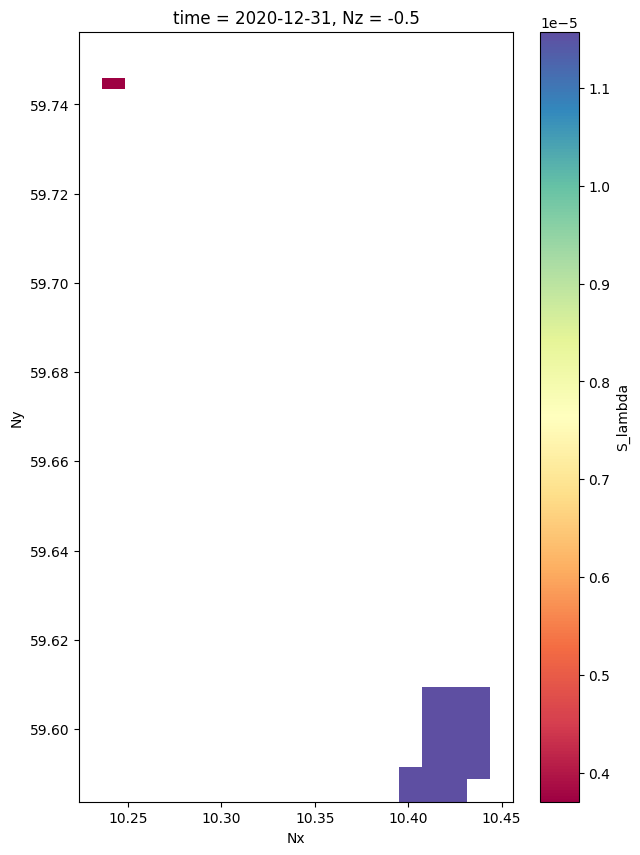

In [37]:
ds.S_lambda.isel(time=-1, Nz=-1).where(lambda x: x != 0).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [38]:
# Lierelva (#17)
y, x = 63, 4 #63, 11 #63, 5 ###95, 8   
layers_num = 3
# y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["v"].values[:, -layers_num:, y + 1, x] = get_river_dis("river_N3_n_from_17_year_2020.csv", 1, layers_num=layers_num)/layers_num # negative flux means 'to the south'
#ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["v_lambda"].values[:, -layers_num:, y + 1, x] =  -2   # this lambda means flux in 'y' direction
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["S"].values[:, -layers_num:, y, x] =  get_river("river_S_from_17_year_2020.csv")
ds["S_lambda"].values[:, -layers_num:, y, x] = river_lambda 
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["NUT"].values[:, -layers_num:, y, x] =  get_river("river_N3_n_from_17_year_2020.csv", layers_num=layers_num)
ds["NUT_lambda"].values[:, -layers_num:, y, x] = river_lambda
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["Ci_free"].values[:, -layers_num:, y, x] =  get_river("river_MP_from_17_year_2020.csv", layers_num=layers_num)
ds["Ci_free_lambda"].values[:, -layers_num:, y, x] = river_lambda
ds["Ci_free"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["Ci_free"][:, :, :, :])

Fill in river_indices with valid cell y, x coordinates

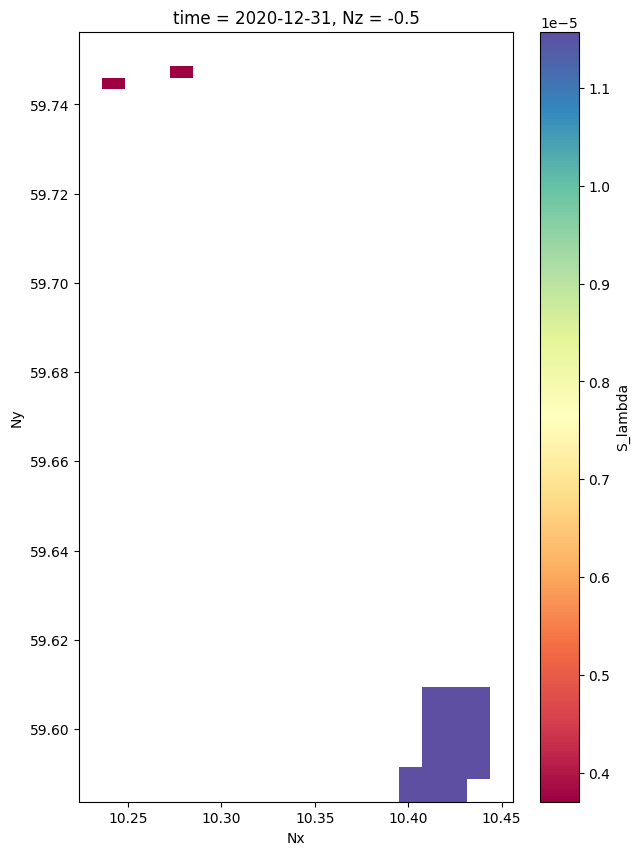

In [39]:
ds.S_lambda.isel(time=-1, Nz=-1).where(lambda x: x != 0).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

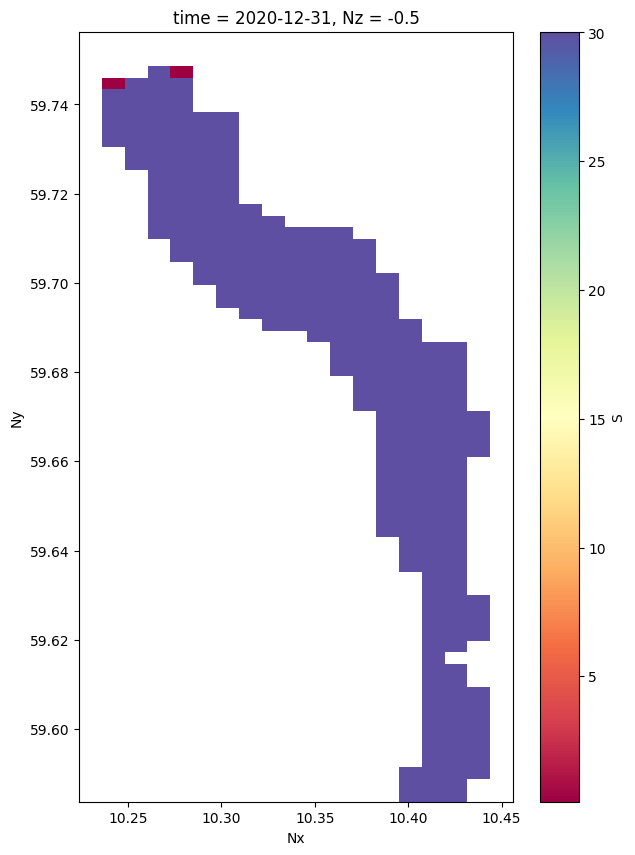

In [40]:
ds.S.isel(time=-1, Nz=-1).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))


Put rivers into the forcing dataset

### Save

In [41]:
encoding = {var: {"zlib": True, "complevel": 5} for var in ds.data_vars}
ds.to_netcdf(
    os.path.join(Path.home(), "src", "gcp-chem-sim-private", "data", "input", "forcing_drammen5.nc"),
    encoding=encoding,
)